Setting directories and device

In [1]:
from google.colab import drive
import torch
import os

drive.mount('/content/drive')
notebook_path = '/content/drive/My Drive/Colab Notebooks/SC4001 AY2526 Project'
os.chdir(notebook_path)
torch.hub.set_dir(notebook_path)
print("Current working directory:", os.getcwd())

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Mounted at /content/drive
Current working directory: /content/drive/My Drive/Colab Notebooks/SC4001 AY2526 Project
Using device: cpu


Importing modules and setting seeds

In [2]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, default_collate

import torchvision
from torchvision.transforms import v2
from torchvision import datasets, transforms, models

import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True

Choose the pretrained torchvision models that will be used on the dataset and create a function and class to appropriately configure them for the dataset and triplet loss

In [3]:
# Define model configurations as a list of dicts
model_configs = [
    {
        "name": "VGG-11_BN",
        "model_fn": models.vgg11_bn,
        "weights": models.VGG11_BN_Weights.IMAGENET1K_V1,
        "classifier_attr": "classifier",
        "classifier_layer_index": -1   # VGG: last layer of classifier
    },
    {
        "name": "ResNet18",
        "model_fn": models.resnet18,
        "weights": models.ResNet18_Weights.IMAGENET1K_V1,
        "classifier_attr": "fc",
        "classifier_layer_index": None  # ResNet: just replace model.fc
    },
    {
        "name": "Swin_T",
        "model_fn": models.swin_t,
        "weights": models.Swin_T_Weights.IMAGENET1K_V1,
        "classifier_attr": "head",
        "classifier_layer_index": None # Swin_T: just replace model.head
    }
]

BATCH_SIZE = 128
NUM_FLOWER_CLASSES = 102

class JointModel(nn.Module):
    """Model that outputs both embeddings (for triplet loss) and logits (for classification)"""
    def __init__(self, backbone, in_features, embedding_dim=128, num_classes=NUM_FLOWER_CLASSES):
        super().__init__()
        self.backbone = backbone
        self.embedding_head = nn.Linear(in_features, embedding_dim)
        self.classifier = nn.Linear(in_features, num_classes)

    def forward(self, x):
        features = self.backbone(x)
        embeddings = self.embedding_head(features)
        logits = self.classifier(features)
        return embeddings, logits

def process_cfg(cfg, embedding_dim=128):
    """Processes a model config to return a JointModel (embedding + classifier)"""
    # Load pre-trained model
    model = cfg["model_fn"](weights=cfg["weights"])

    # Freeze all layers
    for param in model.parameters():
        param.requires_grad = False

    # Extract the number of input features to the original classifier
    if cfg["classifier_layer_index"] is not None:
        # For VGG: classifier is a Sequential, replace the last layer
        classifier = getattr(model, cfg["classifier_attr"])
        in_features = classifier[cfg["classifier_layer_index"]].in_features
        classifier[cfg["classifier_layer_index"]] = nn.Identity()
    else:
        # For ResNet and Swin: directly replace fc or head
        classifier = getattr(model, cfg["classifier_attr"])
        in_features = classifier.in_features
        setattr(model, cfg["classifier_attr"], nn.Identity())

    # Wrap in JointModel
    joint_model = JointModel(model, in_features, embedding_dim, NUM_FLOWER_CLASSES)
    return joint_model

Create helper functions/classes for a model's training, validation and testing phases and a function `tripletloss` to calculate the triplet loss for the triplet loss experiments


In [4]:
class EarlyStopper:
    def __init__(self, patience=5, min_delta=0.1):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.min_validation_loss = np.inf

    #Stops training if validation loss fails to improve by at least {min_delta} for {patience} consecutive epochs.
    def early_stop(self, validation_loss):
        if validation_loss < (self.min_validation_loss - self.min_delta):
            self.min_validation_loss = validation_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False

def compute_correct(outputs, labels):
    """Compute number of correct predictions."""
    _, predictions = torch.max(outputs, dim=1)
    return (predictions == labels).sum().item()

def train(model, tl, vl, epochs=100):
    """Trains model using combined triplet + cross‑entropy loss"""
    model = model.to(device)

    print(f"Training {model.name} on device: {device}")

    early_stopper = EarlyStopper()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=0.0005)
    triplet_loss_fn, triplet_weight = TripletLoss(), 0.5
    ce_loss_fn, ce_weight = nn.CrossEntropyLoss(), 0.5
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)
    train_accuracies, train_losses, val_accuracies, val_losses, times = [], [], [], [], epochs

    for epoch in range(epochs):
        # Training phase
        model.train()
        epoch_train_loss = 0.0
        epoch_train_correct = 0
        for X_batch, y_batch in tl:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            embeddings, logits = model(X_batch)

            # Triplet loss on embeddings
            trip_loss = triplet_loss_fn(embeddings, y_batch)
            # Cross‑entropy loss on logits
            ce_loss = ce_loss_fn(logits, y_batch)
            # Combined loss
            loss = triplet_weight * trip_loss + ce_weight * ce_loss

            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item()
            epoch_train_correct += compute_correct(logits, y_batch) # accuracy from logits
        avg_train_loss = epoch_train_loss / len(tl)
        avg_train_acc = epoch_train_correct / len(tl.dataset)

        # Validation phase
        model.eval()
        epoch_val_loss = 0.0
        epoch_val_correct = 0
        with torch.no_grad():
            for X_batch, y_batch in vl:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                embeddings, logits = model(X_batch)
                ce_loss = ce_loss_fn(logits, y_batch)
                epoch_val_loss += ce_loss.item()
                epoch_val_correct += compute_correct(logits, y_batch)
        avg_val_loss = epoch_val_loss / len(vl)
        avg_val_acc = epoch_val_correct / len(vl.dataset)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accuracies.append(avg_train_acc)
        val_accuracies.append(avg_val_acc)
        scheduler.step()

        if (epoch + 1) % 20 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] "
                f"Train Loss: {avg_train_loss:.4f}, Train Acc: {avg_train_acc:.4f}, "
                f"Val Loss: {avg_val_loss:.4f}, Val Acc: {avg_val_acc:.4f}")

        # Early stopping check (using val loss)
        if early_stopper.early_stop(avg_val_loss):
            times = epoch + 1
            print(f"Early stopping triggered at epoch {times}")
            break

    print(f"\nFinal Train Accuracy: {train_accuracies[-1]:.4f}")
    print(f"Final Val Accuracy: {val_accuracies[-1]:.4f}")

    return train_accuracies, train_losses, val_accuracies, val_losses, times

def test(model, ttl):
    """Evaluates model on test set using the classifier head (logits)"""
    torch.cuda.empty_cache()
    model = model.to(device)
    loss_fn = nn.CrossEntropyLoss()

    print(f"Testing {model.name} on device: {device}")

    # Testing phase
    model.eval()
    test_loss = 0.0
    test_correct = 0
    with torch.no_grad():
        for X_batch, y_batch in ttl:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            _, logits = model(X_batch) # ignore embeddings
            loss = loss_fn(logits, y_batch)
            test_loss += loss.item()
            test_correct += compute_correct(logits, y_batch)
    avg_test_loss = test_loss / len(ttl)
    avg_test_acc = test_correct / len(ttl.dataset)

    print(f"Test Loss: {avg_test_loss:.4f}, Test Acc: {avg_test_acc:.4f}")

    return avg_test_acc, avg_test_loss

class TripletLoss(nn.Module):
    """Online Batch All Triplet Loss: Mines all valid (anchor, positive, negative) combinations
    using pairwise distance matrices; averages over positive losses only, to ignore easy triplets.
    Args:
        margin (float): Triplet loss margin. Default: 1.0.
    Usage:
        loss_fn = TripletLoss()
    """
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin

    def _pairwise_distances(self, outputs):
        """Returns pairwise squared Euclidean distance matrix of shape (B, B)."""
        diff = outputs.unsqueeze(0) - outputs.unsqueeze(1)  # (B, B, embed_dim)
        return (diff ** 2).sum(dim=2)                        # (B, B)

    def _pair_masks(self, labels):
        """Returns (pos_mask, neg_mask) boolean tensors of shape (B, B),
        excluding self-pairs on the diagonal."""
        eye      = torch.eye(len(labels), dtype=torch.bool, device=labels.device)
        pos_mask = (labels.unsqueeze(1) == labels.unsqueeze(0)) & ~eye
        neg_mask = (labels.unsqueeze(1) != labels.unsqueeze(0))
        return pos_mask, neg_mask

    def _online_batch_all(self, dist, pos_mask, neg_mask):
        """Mines all valid triplets; averages over non-zero losses only."""
        # Broadcast: loss(a,p,n) = dist(a,p) - dist(a,n) + margin
        # Shape: (B, B, B) — axes are (anchor, positive, negative)
        loss_all   = dist.unsqueeze(2) - dist.unsqueeze(1) + self.margin  # (B, B, B)
        valid_mask = pos_mask.unsqueeze(2) & neg_mask.unsqueeze(1)        # (B, B, B)
        loss_valid = loss_all[valid_mask]
        hard_mask  = loss_valid > 0
        if hard_mask.sum() == 0:
            return torch.tensor(0.0, requires_grad=True, device=dist.device)
        return loss_valid[hard_mask].mean()

    def forward(self, outputs, labels):
        dist               = self._pairwise_distances(outputs)
        pos_mask, neg_mask = self._pair_masks(labels)
        return self._online_batch_all(dist, pos_mask, neg_mask)

Conduct the triplet loss experiments for each model architecture

In [5]:
triplet_loss_results = []
for cfg in model_configs:
    print(f"\n--- Processing {cfg['name']} ---")

    # Get the official transform
    transform = cfg["weights"].transforms()

    # Create datasets (each model architecture gets its own, but they share the same downloaded images)
    train_dataset = datasets.Flowers102(root='./data', split='train', download=True, transform=transform)
    val_dataset   = datasets.Flowers102(root='./data', split='val',   download=True, transform=transform)
    test_dataset  = datasets.Flowers102(root='./data', split='test',  download=True, transform=transform)

    # Create dataloaders
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    # Load joint model
    model = process_cfg(cfg)
    model.name = cfg["name"] + "_tripletloss"
    save_path = './checkpoints/' + model.name + '.pth'

    if os.path.exists(save_path):
        print(f"\nLoading results from {save_path}")
        ckpt = torch.load(save_path, map_location=device)
        trv_results = ckpt["trv_results"]
        t_results =  ckpt["t_results"]
    else:
        print(f"\n{save_path} does not exist, training from scratch...")

        trv_results = train(model, train_loader, val_loader)
        t_results = test(model, test_loader)

        # Save model state dict
        torch.save({
            'model_state_dict': model.state_dict(),
            'trv_results': trv_results,
            't_results': t_results
        }, save_path)
        print(f"Model saved successfully to {save_path}")

    triplet_loss_results.append({
        "name": model.name,
        "trv_results": trv_results,
        "t_results": t_results
    })

    # After training, delete to free memory
    del model, train_loader, val_loader, test_loader, train_dataset, val_dataset, test_dataset
    torch.cuda.empty_cache()


--- Processing VGG-11_BN ---

Loading results from ./checkpoints/VGG-11_BN_tripletloss.pth

--- Processing ResNet18 ---

Loading results from ./checkpoints/ResNet18_tripletloss.pth

--- Processing Swin_T ---

Loading results from ./checkpoints/Swin_T_tripletloss.pth


Parse the results from the triplet loss experiments and show some of the results as tables and plots (include the results from 10 shot learning as a reference)


Loading results from ./checkpoints/VGG-11_BN_10shot.pth

Loading results from ./checkpoints/ResNet18_10shot.pth

Loading results from ./checkpoints/Swin_T_10shot.pth
TRIPLET LOSS RESULTS SUMMARY
    Model               Loss  Epochs Ran  Final Train Acc (%)  Final Val Acc (%)  Final Train Loss  Final Val Loss  Test Acc (%)  Test Loss
VGG-11_BN       Triplet Loss           9                99.90              84.31          117.4141          0.6123         81.30     0.6924
 ResNet18       Triplet Loss          12                99.80              84.61           14.1588          0.7396         82.50     0.8023
   Swin_T       Triplet Loss          12                99.12              88.04           11.5120          0.5685         86.01     0.6129
VGG-11_BN Cross-Entropy Loss           9                99.90              83.63            0.0162          0.6372         80.99     0.7253
 ResNet18 Cross-Entropy Loss          11               100.00              84.80            0.0856      

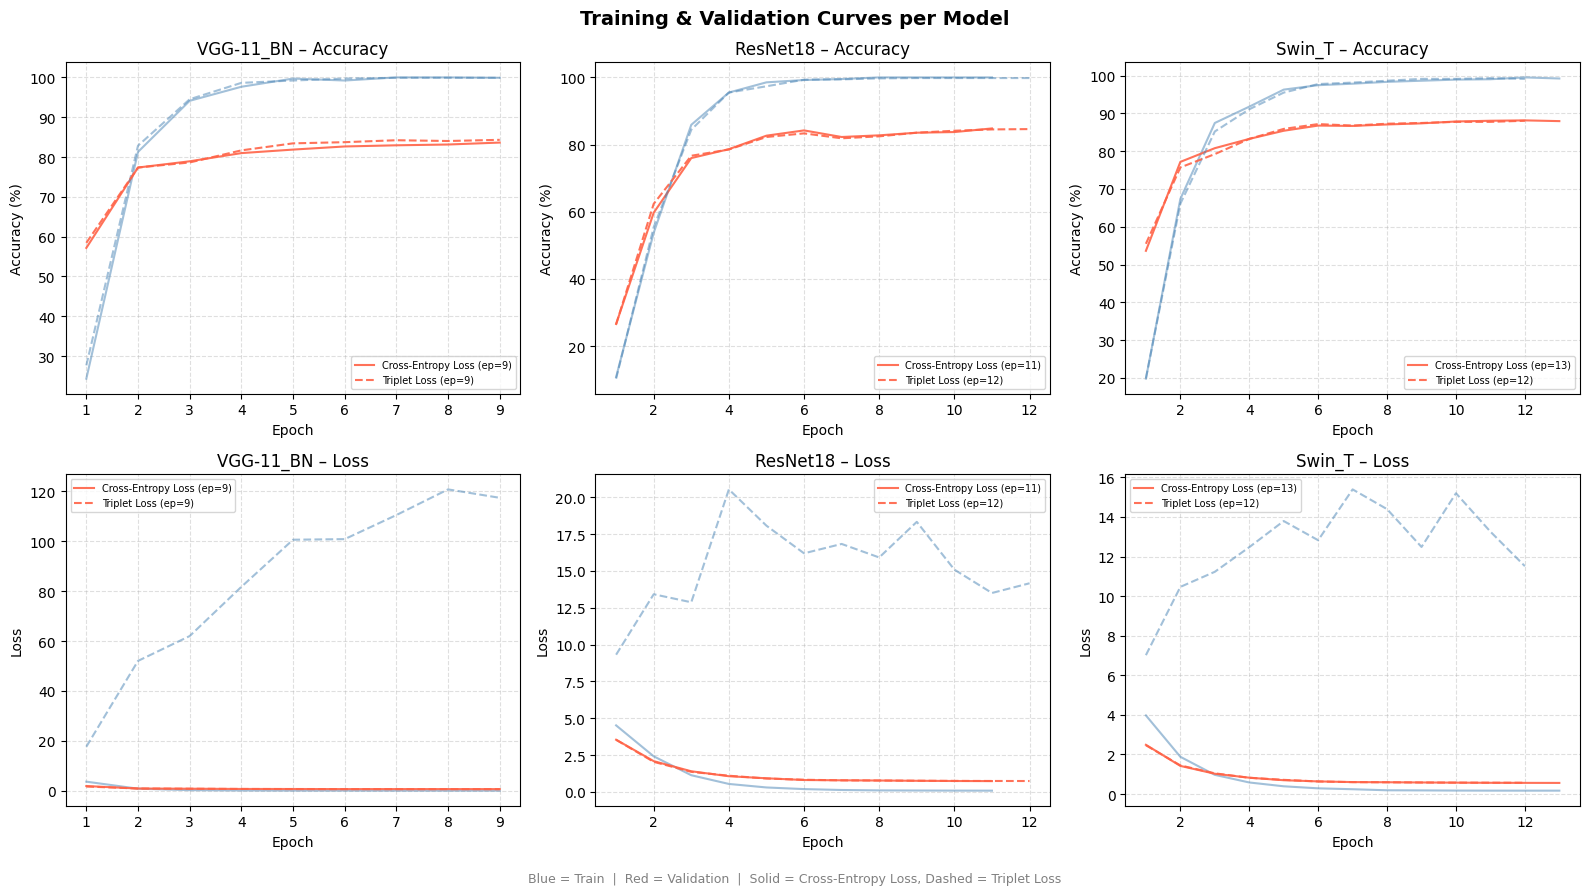

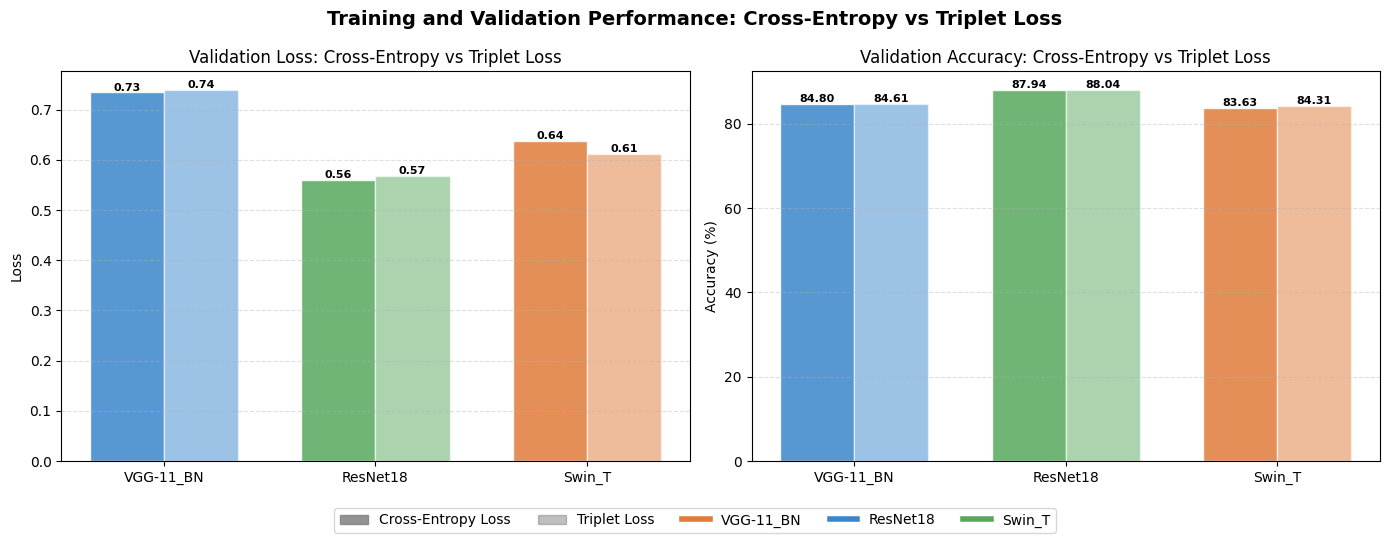

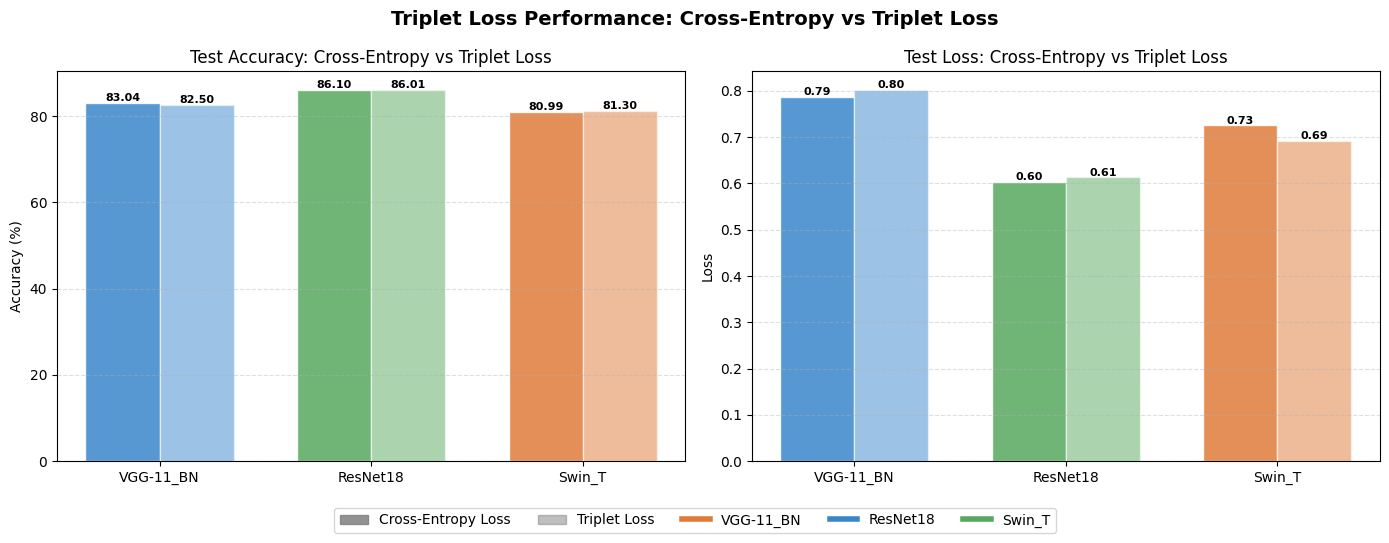

In [6]:
# Parse triplet_loss_results
models_list  = ['VGG-11_BN', 'ResNet18', 'Swin_T']

# Add 10 shot learning results into triplet_loss_results
for model in models_list:
    model_name = model + "_10shot"
    save_path = './checkpoints/' + model_name + '.pth'

    if os.path.exists(save_path):
        print(f"\nLoading results from {save_path}")
        ckpt = torch.load(save_path, map_location=device)
        triplet_loss_results.append({
            "name": model_name,
            "trv_results": ckpt["trv_results"],
            "t_results": ckpt["t_results"]
        })
    else:
        print(f"\n{save_path} does not exist, skip inclusion...")

rows = []
for entry in triplet_loss_results:
    name = entry['name']                       # e.g. 'ResNet18_tripletloss'
    train_accs, train_losses, val_accs, val_losses, epochs_ran = entry['trv_results']
    test_acc, test_loss = entry['t_results']

    # Parse model name and transform from the stored name string
    parts  = name.rsplit('_', 1)               # ['ResNet18', 'tripletloss']
    model  = parts[0]
    loss  = "Triplet Loss" if parts[1] == 'tripletloss' else 'Cross-Entropy Loss'

    rows.append({
        'Model':               model,
        'Loss':                loss,
        'Epochs Ran':          epochs_ran,
        'Final Train Acc (%)': round(train_accs[-1]  * 100, 2),
        'Final Train Loss':    round(train_losses[-1],      4),
        'Final Val Acc (%)':   round(val_accs[-1]    * 100, 2),
        'Final Val Loss':      round(val_losses[-1],        4),
        'Test Acc (%)':        round(test_acc        * 100, 2),
        'Test Loss':           round(test_loss,             4),
        # keep raw lists for plotting
        '_train_accs':         train_accs,
        '_val_accs':           val_accs,
        '_train_losses':       train_losses,
        '_val_losses':         val_losses
    })

df_full = pd.DataFrame(rows)

# Summary tables
display_cols = ['Model', 'Loss', 'Epochs Ran',
                'Final Train Acc (%)', 'Final Val Acc (%)', 'Final Train Loss', 'Final Val Loss',
                'Test Acc (%)', 'Test Loss']

print("="*105)
print("TRIPLET LOSS RESULTS SUMMARY")
print("="*105)
print(df_full[display_cols].to_string(index=False))

# Best val accuracy per model (TL vs CE per architecture)
print("\n" + "─"*105)
print("BEST VAL ACCURACY PER MODEL ARCHITECTURE")
print("─"*105)
best = df_full.loc[df_full.groupby('Model')['Final Val Acc (%)'].idxmax(),
                   ['Model', 'Loss', 'Final Val Acc (%)', 'Final Val Loss']]
print(best.to_string(justify="center", index=False), "\n")

# Color palette
COLORS  = {'VGG-11_BN': '#e07b39', 'ResNet18': '#3a86cc', 'Swin_T': '#57a85e'}
MARKERS = {'VGG-11_BN': 'o',       'ResNet18': 's',        'Swin_T': '^'}
STYLES  = {'Cross-Entropy Loss': '-', 'Triplet Loss': '--'}

# Plots: Training curves – accuracy and loss per model architecture (2×3 grid)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Training & Validation Curves per Model', fontsize=14, fontweight='bold')

for col, model in enumerate(models_list):
    sub = df_full[df_full['Model'] == model].sort_values('Loss')
    ax_acc  = axes[0][col]
    ax_loss = axes[1][col]

    for _, row in sub.iterrows():
        ls      = row['Loss']
        ep      = row['Epochs Ran']
        epochs  = range(1, len(row['_train_accs']) + 1)
        style   = STYLES[ls]
        label   = f'{ls} (ep={ep})'

        ax_acc.plot(epochs, [a * 100 for a in row['_train_accs']],
                    linestyle=style, color='steelblue', alpha=0.5)
        ax_acc.plot(epochs, [a * 100 for a in row['_val_accs']],
                    linestyle=style, color='tomato',    alpha=0.9,
                    label=label)

        ax_loss.plot(epochs, row['_train_losses'],
                     linestyle=style, color='steelblue', alpha=0.5)
        ax_loss.plot(epochs, row['_val_losses'],
                     linestyle=style, color='tomato',    alpha=0.9,
                     label=label)

    ax_acc.set(title=f'{model} – Accuracy',
               xlabel='Epoch', ylabel='Accuracy (%)')
    ax_acc.legend(fontsize=7); ax_acc.grid(True, linestyle='--', alpha=0.4)

    ax_loss.set(title=f'{model} – Loss',
                xlabel='Epoch', ylabel='Loss')
    ax_loss.legend(fontsize=7); ax_loss.grid(True, linestyle='--', alpha=0.4)

# Shared legend hint
fig.text(0.5, 0.01,
         'Blue = Train  |  Red = Validation  |  Solid = Cross-Entropy Loss, Dashed = Triplet Loss',
         ha='center', fontsize=9, color='gray')
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

# Plots: Final Train & Val Loss and Accuracy - Cross-Entropy vs Triplet Loss per architecture
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training and Validation Performance: Cross-Entropy vs Triplet Loss', fontsize=14, fontweight='bold')

losses = ['Cross-Entropy Loss', 'Triplet Loss']
x          = np.arange(len(models_list))
bar_width  = 0.35

for ax, metric, title, ylabel in zip(
        axes,
        ['Final Val Loss', 'Final Val Acc (%)'],
        ['Validation Loss: Cross-Entropy vs Triplet Loss', 'Validation Accuracy: Cross-Entropy vs Triplet Loss'],
        ['Loss', 'Accuracy (%)']):
    for i, loss in enumerate(losses):
        sub  = df_full[df_full['Loss'] == loss].sort_values('Model')
        bars = ax.bar(x + i * bar_width, sub[metric].values,
                      width=bar_width, label=loss,
                      color=[COLORS[m] for m in sub['Model']],
                      edgecolor='white', alpha=0.85 if loss == 'Cross-Entropy Loss' else 0.5)
        # Annotate each bar with its value
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, h,
                    f'{h:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set(title=title, ylabel=ylabel,
           xticks=x + bar_width / 2, xticklabels=models_list)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

# Shared legend: opacity encodes Cross-Entropy vs Triplet Loss, color encodes model architecture
style_handles = [
    plt.Rectangle((0, 0), 1, 1, color='gray', alpha=0.85, label='Cross-Entropy Loss'),
    plt.Rectangle((0, 0), 1, 1, color='gray', alpha=0.5,  label='Triplet Loss'),
]
color_handles = [
    plt.Line2D([0], [0], color=COLORS[m], linewidth=4, label=m)
    for m in models_list
]
fig.legend(handles=style_handles + color_handles,
           loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.08), frameon=True)
plt.tight_layout()
plt.show()

# Plots: Test Accuracy and Loss - Cross-Entropy vs Triplet Loss per model architecture
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Triplet Loss Performance: Cross-Entropy vs Triplet Loss', fontsize=14, fontweight='bold')

for ax, metric, title, ylabel in zip(
        axes,
        ['Test Acc (%)', 'Test Loss'],
        ['Test Accuracy: Cross-Entropy vs Triplet Loss', 'Test Loss: Cross-Entropy vs Triplet Loss'],
        ['Accuracy (%)', 'Loss']):
    for i, loss in enumerate(losses):
        sub  = df_full[df_full['Loss'] == loss].sort_values('Model')
        bars = ax.bar(x + i * bar_width, sub[metric].values,
                      width=bar_width, label=loss,
                      color=[COLORS[m] for m in sub['Model']],
                      edgecolor='white', alpha=0.85 if loss == 'Cross-Entropy Loss' else 0.5)
        # Annotate each bar with its value
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, h,
                    f'{h:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set(title=title, ylabel=ylabel,
           xticks=x + bar_width / 2, xticklabels=models_list)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

fig.legend(handles=style_handles + color_handles,
           loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.08), frameon=True)
plt.tight_layout()
plt.show()